# No Flux in 2D Domain (Disk)

## Setup

### Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

import os

In [2]:
import sys
sys.path.append("..")

### Import custom functions

In [3]:
from sources.simulation import *
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

### Parameters

In [4]:
n_parts = 100000
T = 2

radius = 1.0
bins = 75
theta_bins = 40
r_bins = 10
boundary_width = 0.1

cmap = plt.get_cmap()



b = np.array([1.0, 1.0])
# sigma = np.eye(2)
sigma = np.array([[1.0, 0.5],[0.5, 1.0]])

problem_path = "./data/disk_b-1-1_s-M"
boundary_types = ["reflection", "rejection"]
dt_list = [0.16, 0.04, 0.01]

## Exact stationary density

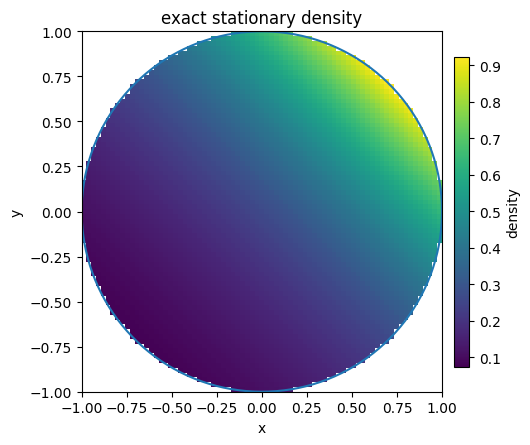

In [5]:
x_edges_exact = np.linspace(-radius, radius, bins + 1)
y_edges_exact = np.linspace(-radius, radius, bins + 1)

x_centres_exact = 0.5*(x_edges_exact[:-1] + x_edges_exact[1:])
y_centres_exact = 0.5*(y_edges_exact[:-1] + y_edges_exact[1:])

x_mesh_exact, y_mesh_exact = np.meshgrid(x_centres_exact, y_centres_exact, indexing="ij")
p_exact = stationary_solution_disk(x_mesh_exact, y_mesh_exact, b, sigma, radius=radius)

fig, ax = plt.subplots(figsize=(5, 5))

plot_density_mesh(p_exact, x_edges_exact, y_edges_exact, ax=ax, title="exact stationary density", cmap=cmap, equal_aspect=True)

theta = np.linspace(0, 2*np.pi, 300)
x_boundary, y_boundary = disk_boundary(radius=radius, theta=theta)
ax.plot(x_boundary, y_boundary)
ax.set_xlim(-radius, radius)
ax.set_ylim(-radius, radius)

fig.colorbar(ax.collections[0], ax=ax, label="density", fraction=0.04, pad=0.03)
plt.show()

## Numerical solutions in the full disk

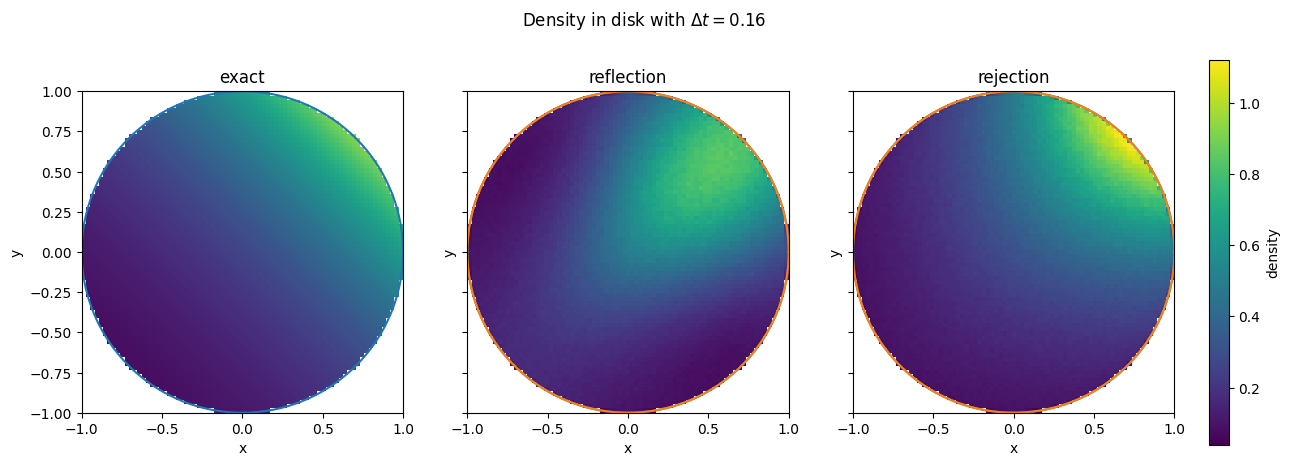

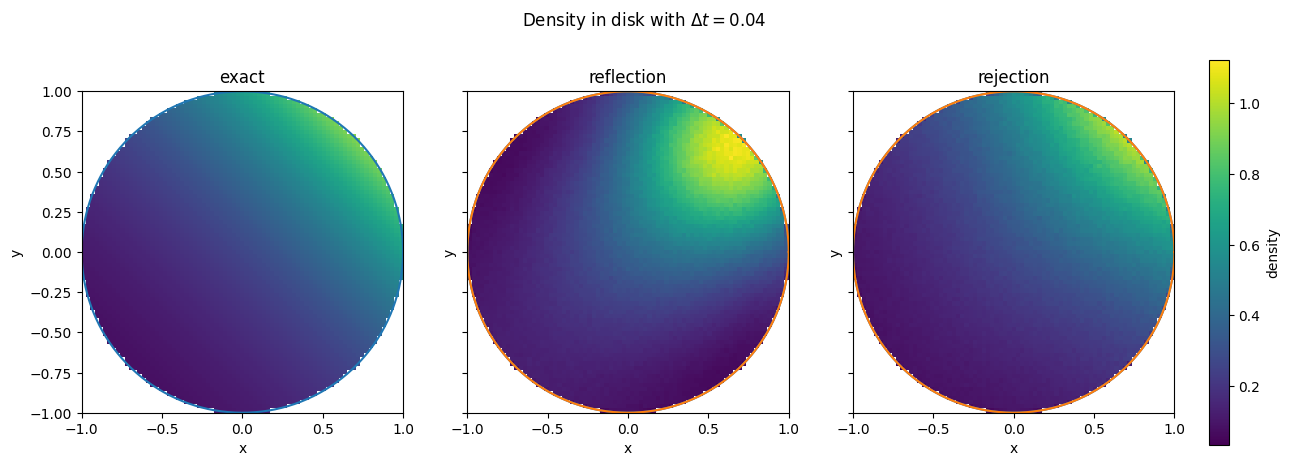

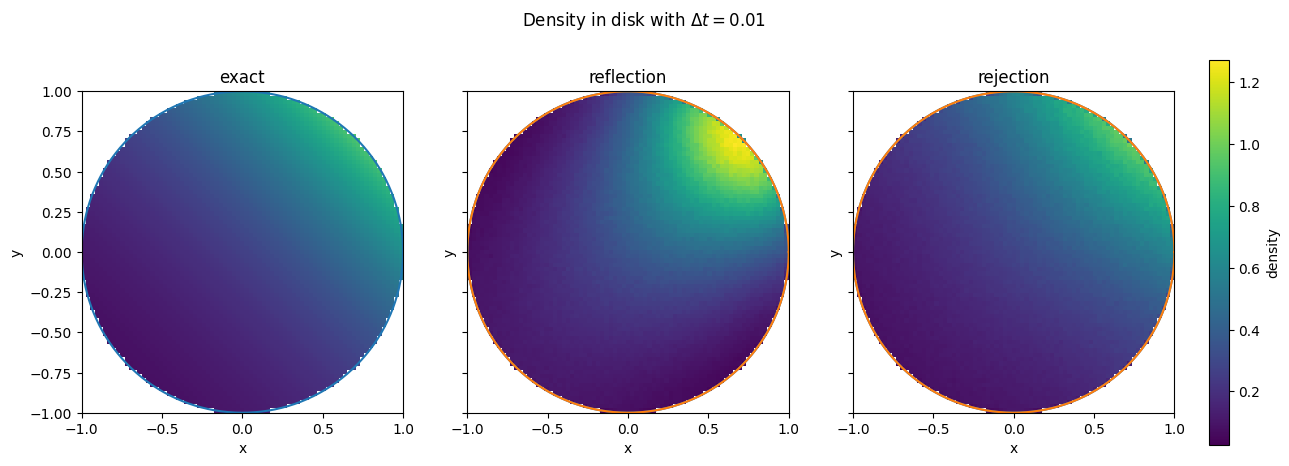

In [6]:
for dt in dt_list:

    p_scales = []

    x_edges = np.linspace(-radius, radius, bins + 1)
    y_edges = np.linspace(-radius, radius, bins + 1)
    x_centres = 0.5*(x_edges[:-1] + x_edges[1:])
    y_centres = 0.5*(y_edges[:-1] + y_edges[1:])
    x_mesh, y_mesh = np.meshgrid(x_centres, y_centres, indexing="ij")

    p_exact = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)
    p_scales.append(p_exact)

    for boundary_type in boundary_types:
        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        p, _, _ = histogram_density_disk(X, radius=radius, bins=bins)
        p_scales.append(p)

    colorbar_values = get_colorbar_values_2d(p_scales)

    fig, ax = plt.subplots(1, len(boundary_types) + 1, figsize=(5*(len(boundary_types) + 1), 5), sharex=True, sharey=True)
    ax = np.atleast_1d(ax)

    fig.suptitle(fr"Density in disk with $\Delta t={dt}$")

    plot_density_mesh(p_exact, x_edges, y_edges, ax=ax[0], title="exact", colorbar_values=colorbar_values, cmap=cmap, equal_aspect=True)

    for i, boundary_type in enumerate(boundary_types):
        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        plot_histogram_disk(X, radius=radius, bins=bins, ax=ax[i+1], title=boundary_type, colorbar_values=colorbar_values, cmap=cmap)

    theta = np.linspace(0, 2*np.pi, 300)
    x_boundary, y_boundary = disk_boundary(radius=radius, theta=theta)

    for a in ax:
        a.plot(x_boundary, y_boundary)
        a.set_xlim(-radius, radius)
        a.set_ylim(-radius, radius)

    vmin, vmax = colorbar_values
    mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    fig.colorbar(mappable, ax=ax.ravel().tolist(), label="density", fraction=0.03, pad=0.03)

    plt.show()

## Local error in the full disk

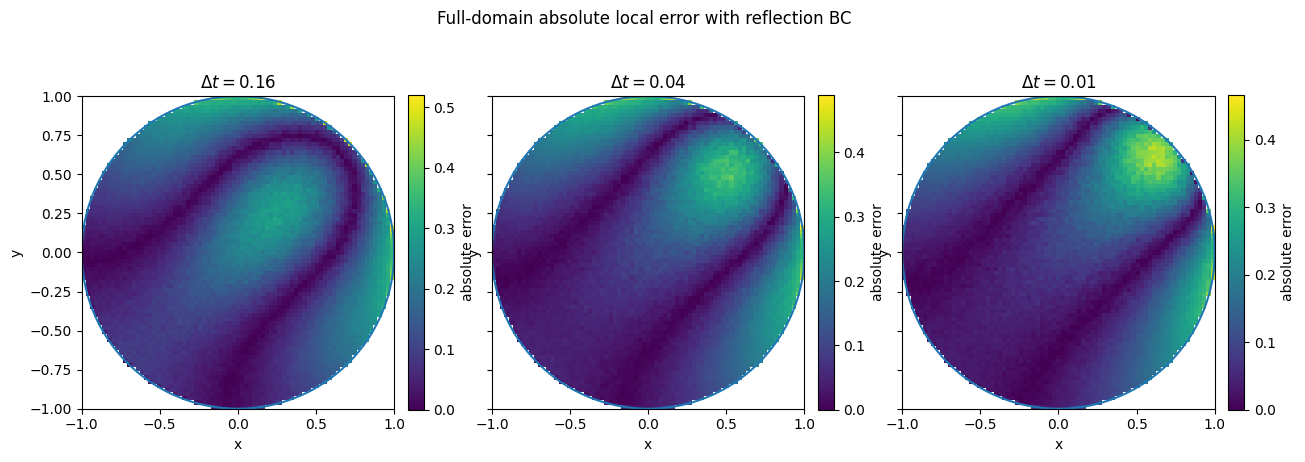

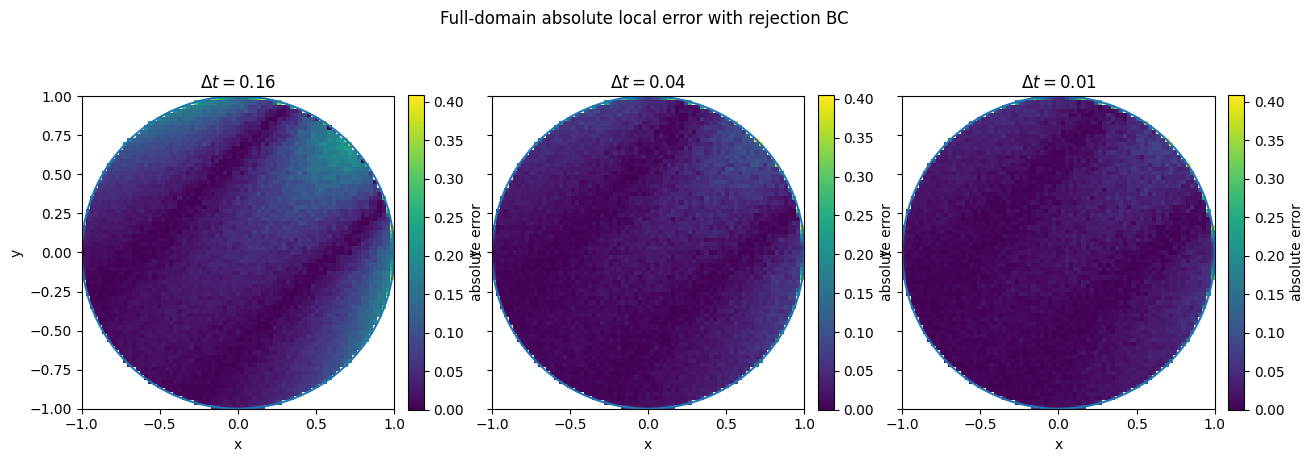

,boundary_type,dt,epsilon,L1_error,L2_error
0,reflection,0.16,0.4,0.368100,0.255649
1,reflection,0.04,0.2,0.331343,0.244068
2,reflection,0.01,0.1,0.316686,0.242627
3,rejection,0.16,0.4,0.154182,0.121320
4,rejection,0.04,0.2,0.082498,0.069791
5,rejection,0.01,0.1,0.063888,0.058341


In [7]:
full_error_rows = []

for boundary_type in boundary_types:

    fig, ax = plt.subplots(1, len(dt_list), figsize=(5*len(dt_list), 5), sharex=True, sharey=True)
    ax = np.atleast_1d(ax)
    fig.suptitle(f"Full-domain absolute local error with {boundary_type} BC")

    for i, dt in enumerate(dt_list):

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, x_edges, y_edges = histogram_density_disk(X, radius=radius, bins=bins)

        x_centres = 0.5*(x_edges[:-1] + x_edges[1:])
        y_centres = 0.5*(y_edges[:-1] + y_edges[1:])
        x_mesh, y_mesh = np.meshgrid(x_centres, y_centres, indexing="ij")

        p_true = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

        error = local_error_density(p_num, p_true)
        abs_error = np.abs(error)

        L1_error, L2_error = density_error_norms_cartesian(error, x_edges, y_edges)

        full_error_rows.append({"boundary_type": boundary_type, "dt": dt, "epsilon": np.sqrt(dt), "L1_error": L1_error, "L2_error": L2_error})

        colorbar_values = (0, np.nanmax(abs_error))

        plot_density_mesh(abs_error, x_edges, y_edges, ax=ax[i], title=fr"$\Delta t={dt}$", colorbar_values=colorbar_values, cmap=cmap, equal_aspect=True)

        theta = np.linspace(0, 2*np.pi, 300)
        x_boundary, y_boundary = disk_boundary(radius=radius, theta=theta)
        ax[i].plot(x_boundary, y_boundary)
        ax[i].set_xlim(-radius, radius)
        ax[i].set_ylim(-radius, radius)

        mappable = ScalarMappable(norm=Normalize(vmin=colorbar_values[0], vmax=colorbar_values[1]), cmap=cmap)
        fig.colorbar(mappable, ax=ax[i], label="absolute error", fraction=0.046, pad=0.04)

    plt.show()

full_error_table = pd.DataFrame(full_error_rows)
display(full_error_table)

## Convergence in the full disk

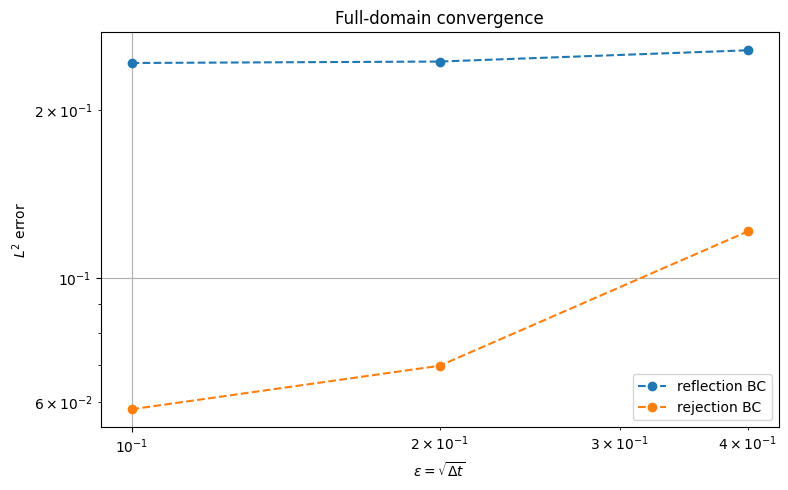

,boundary_type,observed_order_full
0,reflection,0.037714
1,rejection,0.528117


In [8]:
plt.figure(figsize=(8, 5))

full_order_rows = []

for boundary_type in boundary_types:

    rows = full_error_table[full_error_table["boundary_type"] == boundary_type].sort_values("epsilon")

    epsilon_values = rows["epsilon"].to_numpy()
    errors = rows["L2_error"].to_numpy()

    plt.loglog(epsilon_values, errors, marker="o", linestyle="--", label=f"{boundary_type} BC")

    order = np.polyfit(np.log(epsilon_values), np.log(errors), 1)[0]
    full_order_rows.append({"boundary_type": boundary_type, "observed_order_full": order})

plt.xlabel(r"$\varepsilon=\sqrt{\Delta t}$")
plt.ylabel(r"$L^2$ error")
plt.title("Full-domain convergence")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

full_convergence_table = pd.DataFrame(full_order_rows)
display(full_convergence_table)

## Numerical density near the boundary

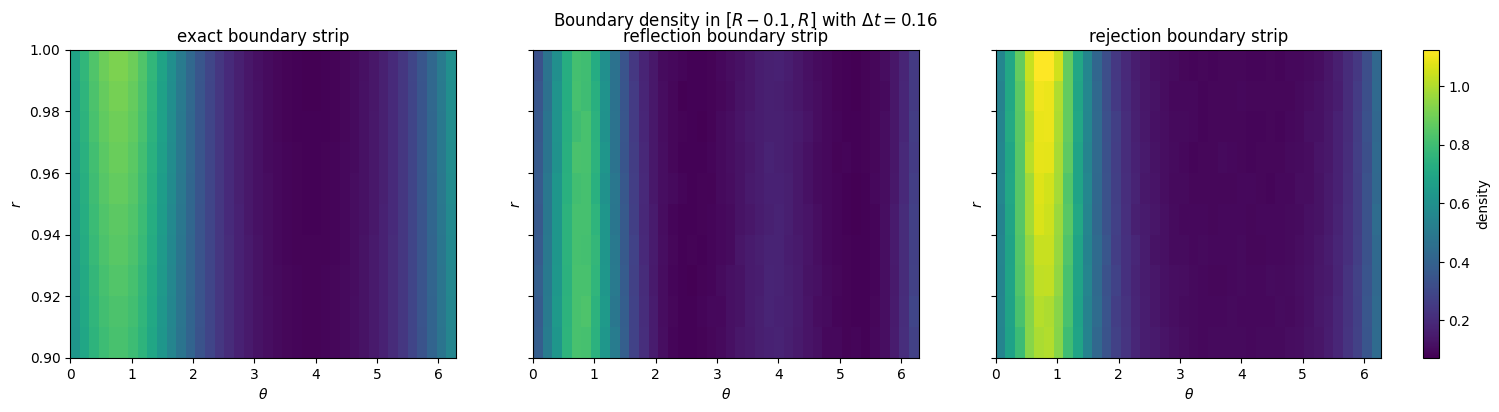

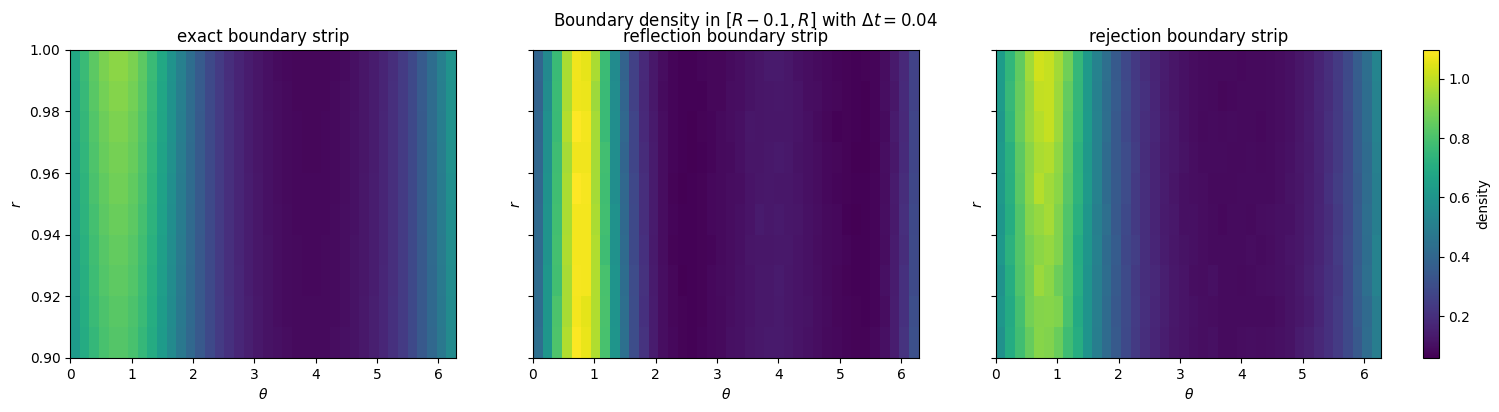

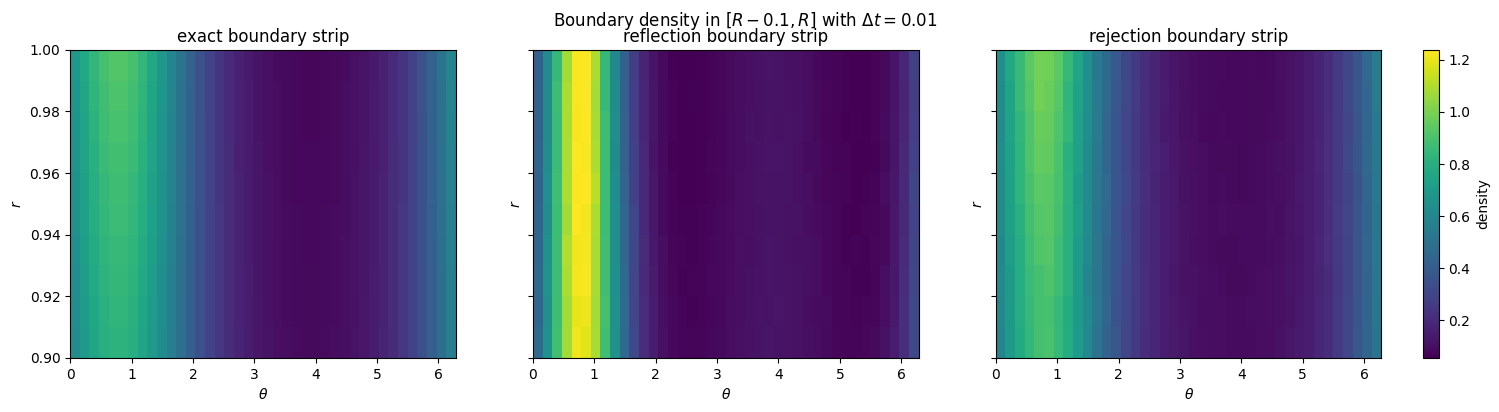

In [9]:
for dt in dt_list:

    r_range = (radius - boundary_width, radius)

    p_scales = []

    theta_edges = np.linspace(0, 2*np.pi, theta_bins + 1)
    r_edges = np.linspace(r_range[0], r_range[1], r_bins + 1)

    theta_centres = 0.5*(theta_edges[:-1] + theta_edges[1:])
    r_centres = 0.5*(r_edges[:-1] + r_edges[1:])
    theta_mesh, r_mesh = np.meshgrid(theta_centres, r_centres, indexing="ij")

    x_mesh = r_mesh*np.cos(theta_mesh)
    y_mesh = r_mesh*np.sin(theta_mesh)

    p_true = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)
    p_scales.append(p_true)

    for boundary_type in boundary_types:
        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        p, _, _, _ = density_disk_range(X, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)
        p_scales.append(p)

    colorbar_values = get_colorbar_values_2d(p_scales)

    fig, ax = plt.subplots(1, len(boundary_types) + 1, figsize=(6*(len(boundary_types) + 1), 4), sharex=True, sharey=True)
    ax = np.atleast_1d(ax)
    fig.suptitle(fr"Boundary density in $[R-{boundary_width}, R]$ with $\Delta t={dt}$")

    plot_density_mesh(p_true, theta_edges, r_edges, ax=ax[0], title="exact boundary strip",
        colorbar_values=colorbar_values, cmap=cmap, x_label=r"$\theta$", y_label=r"$r$",
        equal_aspect=False)

    for i, boundary_type in enumerate(boundary_types):
        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        plot_density_disk_range(X, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins, ax=ax[i+1],
            title=f"{boundary_type} boundary strip", colorbar_values=colorbar_values, cmap=cmap)
        

    vmin, vmax = colorbar_values
    mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    fig.colorbar(mappable, ax=ax.ravel().tolist(), label="density", fraction=0.03, pad=0.03)

    plt.show()

## Local error near the boundary

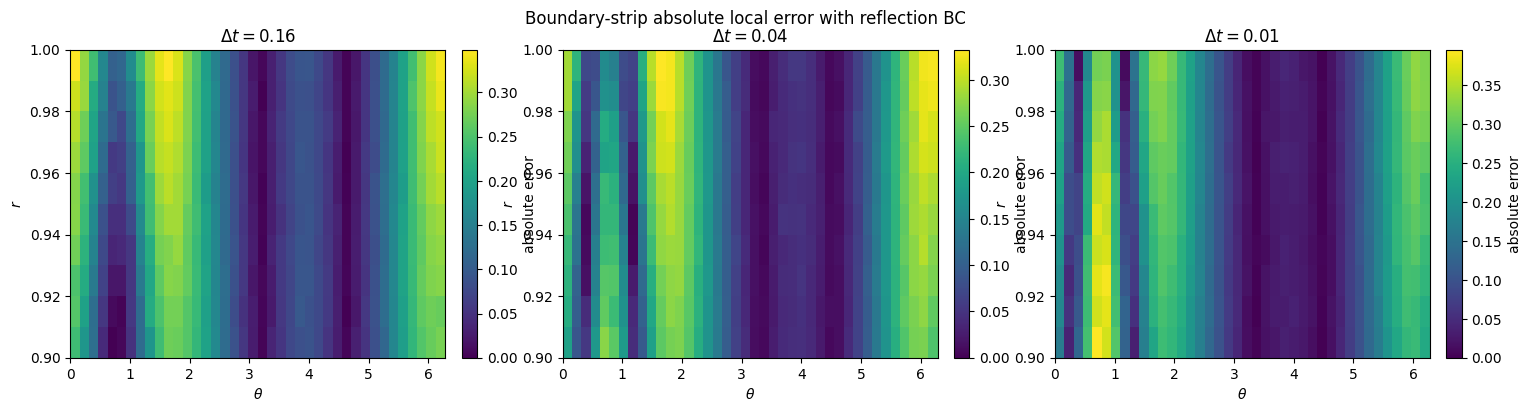

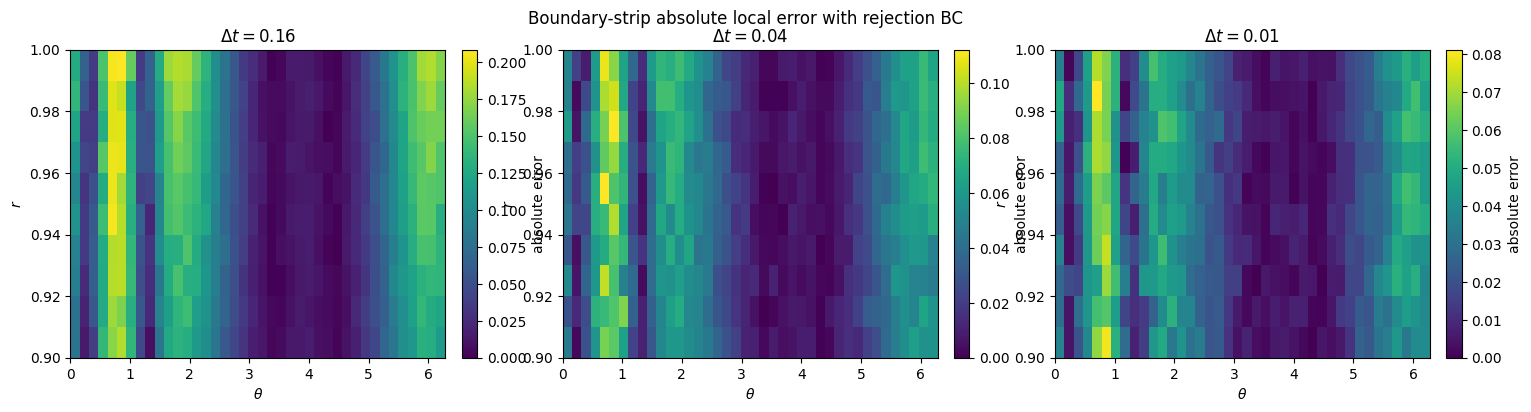

,boundary_type,dt,epsilon,r_width,L1_error,L2_error
0,reflection,0.16,0.4,0.1,0.085665,0.135432
1,reflection,0.04,0.2,0.1,0.081738,0.131473
2,reflection,0.01,0.1,0.1,0.088421,0.143640
3,rejection,0.16,0.4,0.1,0.046016,0.075420
4,rejection,0.04,0.2,0.1,0.021075,0.034279
5,rejection,0.01,0.1,0.1,0.015181,0.024628


In [10]:
boundary_error_rows = []

for boundary_type in boundary_types:

    fig, ax = plt.subplots(1, len(dt_list), figsize=(6*len(dt_list), 4), sharex=False, sharey=False)
    ax = np.atleast_1d(ax)
    fig.suptitle(f"Boundary-strip absolute local error with {boundary_type} BC")

    for i, dt in enumerate(dt_list):

        epsilon = np.sqrt(dt)
        r_range = (radius - boundary_width, radius)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, theta_edges, r_edges, _ = density_disk_range(X, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)

        theta_centres = 0.5*(theta_edges[:-1] + theta_edges[1:])
        r_centres = 0.5*(r_edges[:-1] + r_edges[1:])
        theta_mesh, r_mesh = np.meshgrid(theta_centres, r_centres, indexing="ij")

        x_mesh = r_mesh*np.cos(theta_mesh)
        y_mesh = r_mesh*np.sin(theta_mesh)

        p_true = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

        error = local_error_density(p_num, p_true)
        abs_error = np.abs(error)

        L1_error, L2_error = density_error_norms(error, theta_edges, r_edges)

        boundary_error_rows.append({"boundary_type": boundary_type, "dt": dt, "epsilon": epsilon, "r_width": boundary_width, "L1_error": L1_error, "L2_error": L2_error})

        colorbar_values = (0, np.nanmax(abs_error))

        plot_density_mesh(abs_error, theta_edges, r_edges, ax=ax[i], title=fr"$\Delta t={dt}$", colorbar_values=colorbar_values, cmap=cmap, x_label=r"$\theta$", y_label=r"$r$", equal_aspect=False)

        mappable = ScalarMappable(norm=Normalize(vmin=colorbar_values[0], vmax=colorbar_values[1]), cmap=cmap)
        fig.colorbar(mappable, ax=ax[i], label="absolute error", fraction=0.046, pad=0.04)

    plt.show()

boundary_error_table = pd.DataFrame(boundary_error_rows)
display(boundary_error_table)

## Convergence near the boundary

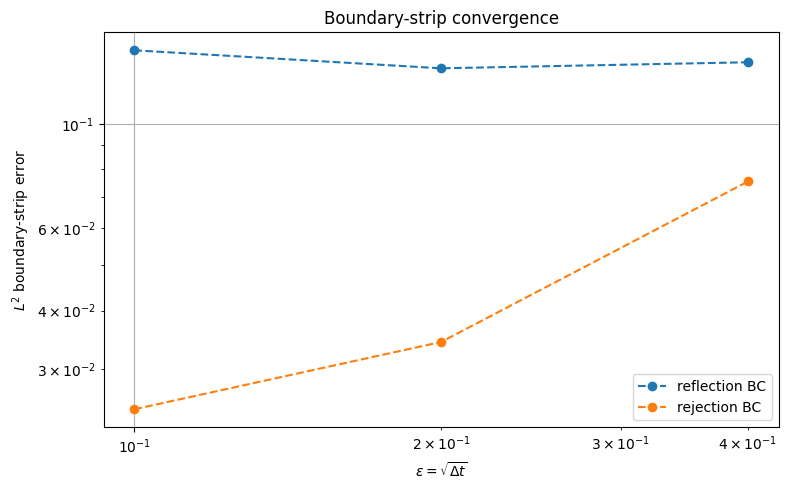

,boundary_type,observed_order_boundary
0,reflection,-0.042442
1,rejection,0.807331


In [11]:
plt.figure(figsize=(8, 5))

boundary_order_rows = []

for boundary_type in boundary_types:

    rows = boundary_error_table[boundary_error_table["boundary_type"] == boundary_type].sort_values("epsilon")

    epsilon_values = rows["epsilon"].to_numpy()
    errors = rows["L2_error"].to_numpy()

    plt.loglog(epsilon_values, errors, marker="o", linestyle="--", label=f"{boundary_type} BC")

    order = np.polyfit(np.log(epsilon_values), np.log(errors), 1)[0]
    boundary_order_rows.append({"boundary_type": boundary_type, "observed_order_boundary": order})

plt.xlabel(r"$\varepsilon=\sqrt{\Delta t}$")
plt.ylabel(r"$L^2$ boundary-strip error")
plt.title("Boundary-strip convergence")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

boundary_convergence_table = pd.DataFrame(boundary_order_rows)
display(boundary_convergence_table)

## Stretched boundary-layer error

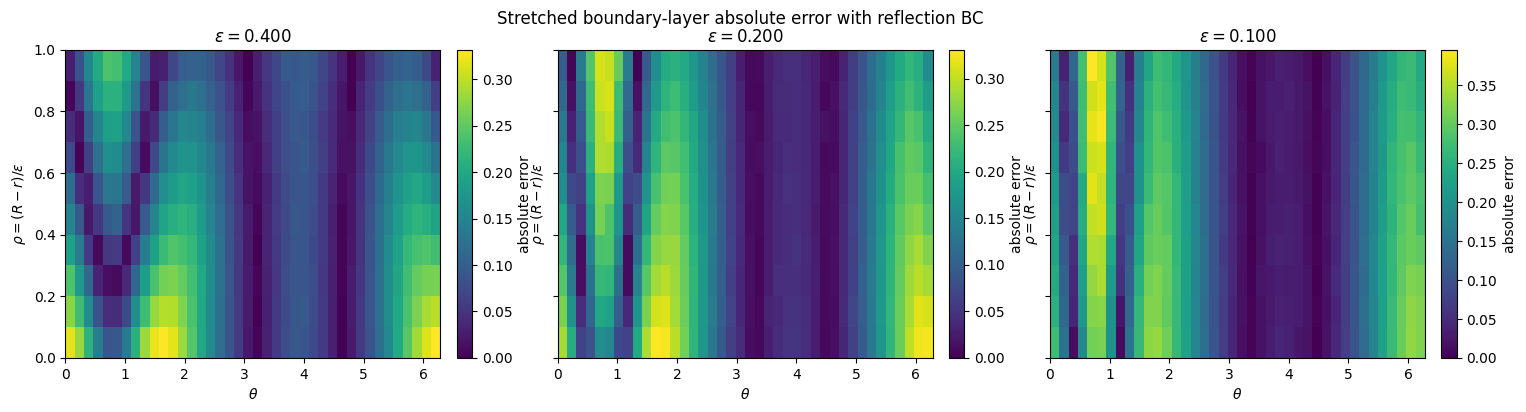

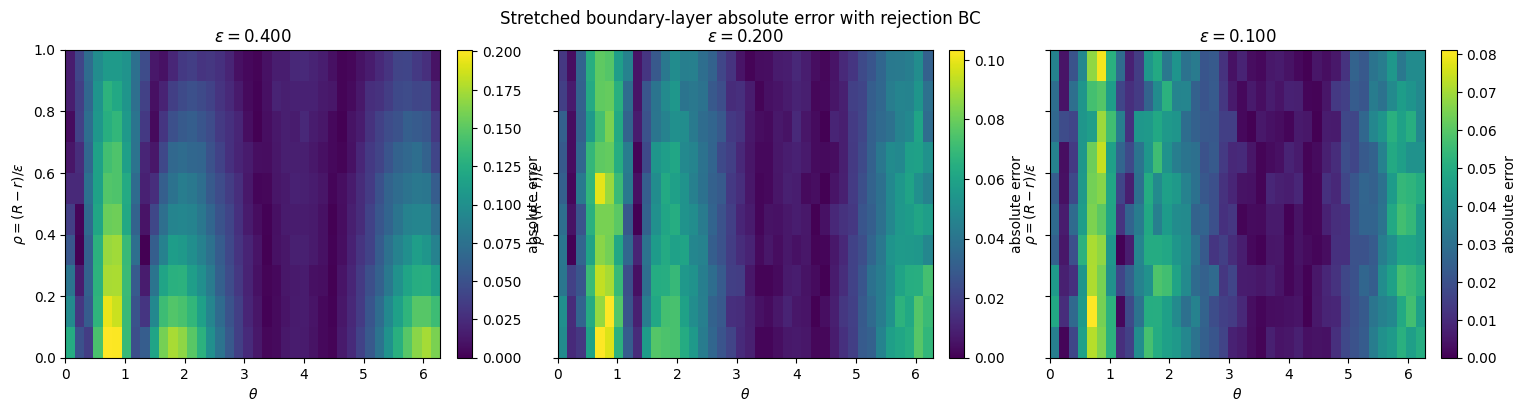

In [12]:
for boundary_type in boundary_types:

    fig, ax = plt.subplots(1, len(dt_list), figsize=(6*len(dt_list), 4), sharex=True, sharey=True)
    ax = np.atleast_1d(ax)
    fig.suptitle(f"Stretched boundary-layer absolute error with {boundary_type} BC")

    for i, dt in enumerate(dt_list):

        epsilon = np.sqrt(dt)
        r_range = (radius - epsilon, radius)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, theta_edges, r_edges, _ = density_disk_range(X, r_range=r_range, theta_bins=theta_bins, r_bins=r_bins)

        theta_centres = 0.5*(theta_edges[:-1] + theta_edges[1:])
        r_centres = 0.5*(r_edges[:-1] + r_edges[1:])
        theta_mesh, r_mesh = np.meshgrid(theta_centres, r_centres, indexing="ij")

        x_mesh = r_mesh*np.cos(theta_mesh)
        y_mesh = r_mesh*np.sin(theta_mesh)

        p_true = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

        error = local_error_density(p_num, p_true)
        abs_error = np.abs(error)

        rho_edges = (radius - r_edges)/epsilon

        colorbar_values = (0, np.nanmax(abs_error))

        plot_density_mesh(abs_error, theta_edges, rho_edges, ax=ax[i], title=fr"$\varepsilon={epsilon:.3f}$", colorbar_values=colorbar_values, cmap=cmap, x_label=r"$\theta$", y_label=r"$\rho=(R-r)/\varepsilon$", equal_aspect=False)

        ax[i].set_ylim(rho_edges[-1], rho_edges[0])

        mappable = ScalarMappable(norm=Normalize(vmin=colorbar_values[0], vmax=colorbar_values[1]), cmap=cmap)
        fig.colorbar(mappable, ax=ax[i], label="absolute error", fraction=0.046, pad=0.04)

    plt.show()